# CNN with Batchnorm and Focal Loss

- 3 convolutional blocks:
    - Conv2D -> BatchNorm2d -> ReLU -> MaxPooling
- Channel progression: 3 -> 32 -> 64 -> 128

**Objective** <br/>
Evaluate whether replacing weighted BCE with focal loss improves anomaly detection performance on the imbalanced HAM10000 task.

**Changes from previous notebook** <br/>
- Keep the BatchNorm CNN architecture
- Replace `BCEWithLogitsLoss` with a custom binary focal loss
- Continue selecting the best checkpoint using validation F2

**Hypothesis** <br/>
Focal loss will focus learning on hard and minority examples, which may improve recall and F2 for melanoma detection.


### 1. Import libraries

In [1]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.cnn_batchnorm import BatchNormCNN
from src.training.trainer import train_one_epoch, validate_one_epoch

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report

os.chdir(ROOT)
print(Path.cwd())


class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        alpha_factor = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_weight = alpha_factor * (1 - pt).pow(self.gamma)
        loss = focal_weight * bce_loss

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning


### 2. Use Cuda else MPS

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: mps


### 3. Split Dataset and Configure Focal Loss
- Use BatchNorm CNN
- Use custom binary focal loss
- Use Adam optimizer


In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv("data_new/splits/train.csv")

# Assumes label 1 is the anomaly / melanoma class.
num_positive = (train_df["label"] == 1).sum()
num_negative = (train_df["label"] == 0).sum()

alpha = num_negative / (num_negative + num_positive)
gamma = 2.0

print(f"Focal alpha: {alpha:.4f}")
print(f"Focal gamma: {gamma:.1f}")

model = BatchNormCNN().to(device)
criterion = BinaryFocalLoss(alpha=alpha, gamma=gamma)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


Focal alpha: 0.8903
Focal gamma: 2.0


### 4. Train Model

In [4]:
model_save_path = os.path.abspath("models/cnn_batchnorm_focalloss.pth")
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
##########
train_f2s = []
val_f2s = []
##########

best_val_f2 = -1.0

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])
    ##########
    train_f2s.append(train_metrics["f2"])
    val_f2s.append(val_metrics["f2"])
    ##########

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Focal Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f}, Train F2: {train_metrics['f2']:.4f} | "
        f"Val Focal Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics["f2"] > best_val_f2:
        best_val_f2 = val_metrics["f2"]
        torch.save(model.state_dict(), model_save_path)
        print("Saved best model at epoch", epoch + 1)


Epoch [1/20] | Train Focal Loss: 0.3765, Train Acc: 0.6380, Train F2: 0.4170 | Val Focal Loss: 0.0300, Val Acc: 0.6077, Val F2: 0.5216
Saved best model at epoch 1


Epoch [2/20] | Train Focal Loss: 0.0298, Train Acc: 0.5933, Train F2: 0.4824 | Val Focal Loss: 0.0267, Val Acc: 0.6981, Val F2: 0.5546
Saved best model at epoch 2


Epoch [3/20] | Train Focal Loss: 0.0283, Train Acc: 0.6192, Train F2: 0.5010 | Val Focal Loss: 0.0274, Val Acc: 0.5010, Val F2: 0.5152


Epoch [4/20] | Train Focal Loss: 0.0282, Train Acc: 0.6372, Train F2: 0.5004 | Val Focal Loss: 0.0263, Val Acc: 0.6853, Val F2: 0.5462


Epoch [5/20] | Train Focal Loss: 0.0289, Train Acc: 0.6668, Train F2: 0.5110 | Val Focal Loss: 0.0258, Val Acc: 0.6008, Val F2: 0.5444


...

Epoch [16/20] | Train Focal Loss: 0.0283, Train Acc: 0.7612, Train F2: 0.5269 | Val Focal Loss: 0.0275, Val Acc: 0.7243, Val F2: 0.5583


Epoch [17/20] | Train Focal Loss: 0.0286, Train Acc: 0.7652, Train F2: 0.5243 | Val Focal Loss: 0.0282, Val Acc: 0.7332, Val F2: 0.5573


Epoch [18/20] | Train Focal Loss: 0.0329, Train Acc: 0.7702, Train F2: 0.4721 | Val Focal Loss: 0.0283, Val Acc: 0.6912, Val F2: 0.5523


Epoch [19/20] | Train Focal Loss: 0.0353, Train Acc: 0.7576, Train F2: 0.4745 | Val Focal Loss: 0.0305, Val Acc: 0.7801, Val F2: 0.4715


Epoch [20/20] | Train Focal Loss: 0.0286, Train Acc: 0.7582, Train F2: 0.5171 | Val Focal Loss: 0.0286, Val Acc: 0.6991, Val F2: 0.5390


### 5. Plot Training Curves
- Loss
- Accuracy
- F2 score


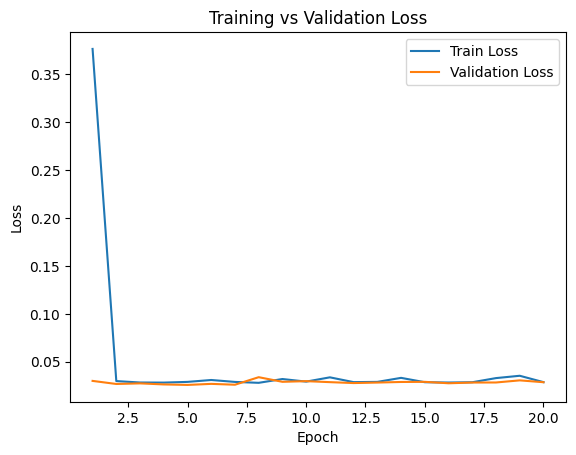

In [5]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

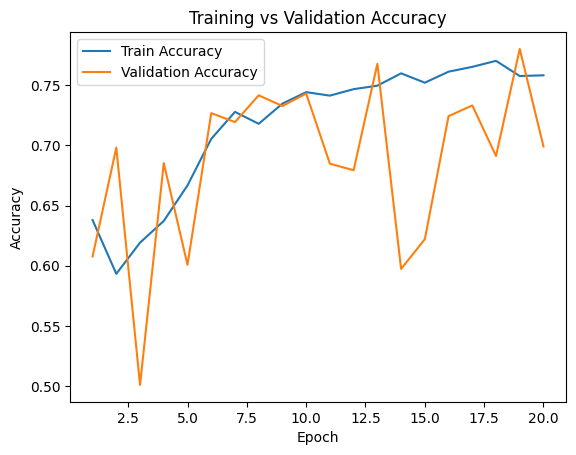

In [6]:
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

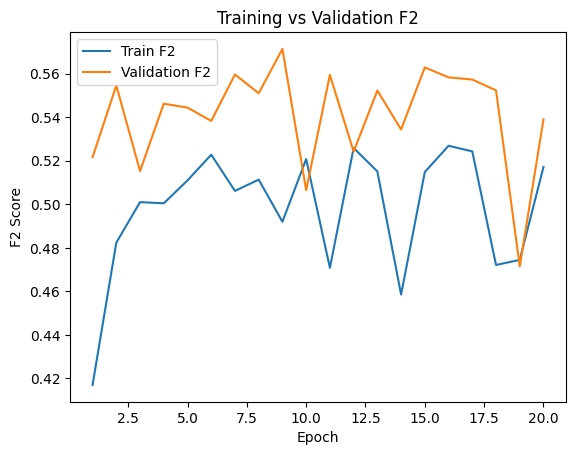

In [7]:
plt.figure()
plt.plot(epochs, train_f2s, label="Train F2")
plt.plot(epochs, val_f2s, label="Validation F2")

plt.xlabel("Epoch")
plt.ylabel("F2 Score")
plt.title("Training vs Validation F2")
plt.legend()
plt.show()

### 6. Tune Threshold on Validation Set
[[TN, FP],<br/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

This section sweeps decision thresholds on the validation set and keeps the threshold with the best F2 score.


In [8]:
from sklearn.metrics import fbeta_score, precision_score, recall_score, balanced_accuracy_score
import numpy as np

model.eval()

val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)

        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

thresholds = np.arange(0.05, 0.95, 0.05)

best_threshold = 0.5
best_f2 = -1

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in val_probs]
    f2 = fbeta_score(val_labels, preds, beta=2)

    print(
        f"Threshold={threshold:.2f} | "
        f"F2={f2:.4f} | "
        f"Precision={precision_score(val_labels, preds):.4f} | "
        f"Recall={recall_score(val_labels, preds):.4f} | "
        f"Balanced Acc={balanced_accuracy_score(val_labels, preds):.4f}"
    )

    if f2 > best_f2:
        best_f2 = f2
        best_threshold = threshold

print(f"\nBest threshold on validation set: {best_threshold:.2f}")


Threshold=0.05 | F2=0.4027 | Precision=0.1188 | Recall=1.0000 | Balanced Acc=0.5106
Threshold=0.10 | F2=0.4055 | Precision=0.1200 | Recall=1.0000 | Balanced Acc=0.5162
Threshold=0.15 | F2=0.4059 | Precision=0.1205 | Recall=0.9958 | Balanced Acc=0.5180
Threshold=0.20 | F2=0.4077 | Precision=0.1213 | Recall=0.9958 | Balanced Acc=0.5217
Threshold=0.25 | F2=0.4081 | Precision=0.1217 | Recall=0.9915 | Balanced Acc=0.5234
Threshold=0.30 | F2=0.4095 | Precision=0.1223 | Recall=0.9915 | Balanced Acc=0.5262
Threshold=0.35 | F2=0.4107 | Precision=0.1228 | Recall=0.9915 | Balanced Acc=0.5285
Threshold=0.40 | F2=0.4118 | Precision=0.1234 | Recall=0.9915 | Balanced Acc=0.5307
Threshold=0.45 | F2=0.5400 | Precision=0.2118 | Recall=0.8814 | Balanced Acc=0.7242
Threshold=0.50 | F2=0.5390 | Precision=0.2463 | Recall=0.7669 | Balanced Acc=0.7286
Threshold=0.55 | F2=0.5151 | Precision=0.3221 | Recall=0.6059 | Balanced Acc=0.7188
Threshold=0.60 | F2=0.3629 | Precision=0.3568 | Recall=0.3644 | Balanced Acc

/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


#### 7. Evaluate on Test Set Using Best Threshold


In [9]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = best_threshold

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= threshold).long()            # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [10]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[726 614]
 [ 13 158]]
              precision    recall  f1-score   support

           0     0.9824    0.5418    0.6984      1340
           1     0.2047    0.9240    0.3351       171

    accuracy                         0.5850      1511
   macro avg     0.5935    0.7329    0.5168      1511
weighted avg     0.8944    0.5850    0.6573      1511



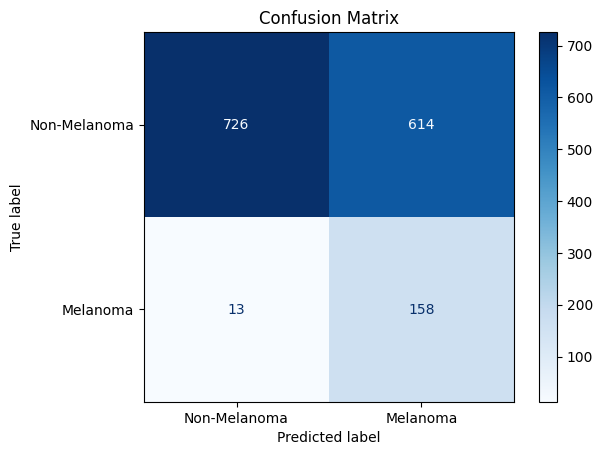

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

- Training accuracy increases to around 75.8%, while validation F2 reaches a peak of 0.5713, indicating that the model is able to learn minority-class patterns more effectively. 
- However, the validation curves remain noisy and do not improve steadily after the middle epochs
- On the test set, the model achieves very high melanoma recall of 92.40%, missing only 13 melanoma cases, but this comes at the expense of 614 false positives, which reduces precision to 20.47% and overall accuracy to 58.50%. 
- Therefore, the corrected focal-loss model is clearly learning, but it is overly biased toward sensitivity and does not provide a good balance between recall and precision.
- In this study, focal loss did not provide a meaningful improvement over weighted loss. Although it further increased melanoma recall, it substantially increased false positives and reduced overall precision, F1-score, and accuracy, making the weighted-loss model the more balanced and practically useful approach.

| Model | Main Change | Accuracy | Melanoma Precision | Melanoma Recall | Melanoma F1 | Main Interpretation |
|---|---|---:|---:|---:|---:|---|
| `01.cnn_baseline` | Plain CNN with standard BCE loss | 0.8848 | 0.4848 | 0.2807 | 0.3556 | High overall accuracy, but poor melanoma detection due to class imbalance |
| `02.cnn_baseline_weighted` | Added `pos_weight` to BCE loss and tuned threshold by F1 | 0.8379 | 0.3706 | 0.6199 | 0.4639 | Best overall balance between melanoma detection and overall classification quality |
| `03.cnn_batchnorm_weighted` | Added BatchNorm to weighted CNN and tuned threshold by F2 | 0.7240 | 0.2560 | 0.7544 | 0.3822 | Higher recall, but much more aggressive and less balanced than `02` |
| `04.cnn_batchnorm_focalloss` | Replaced weighted BCE with focal loss and tuned threshold by F2 | 0.5850 | 0.2047 | 0.9240 | 0.3351 | Highest recall, but excessive false positives and weakest overall balance |
